## A machine learning approach to volatility forecasting


###### In this notebook, I try to replicate the research by Christensen, Siggaard and Veliyev. I use EURUSD exchange rate tick data from November 2025-January 2026, so with intraday trading data (bid and ask).

In [1]:
import numpy as np
import pandas as pd
from numpy.linalg import lstsq

###### First, we load in the exchange rate data, Compute 5-minute log-returns and daily realized variance.

In [3]:
def build_series(
    files=[
        "EURUSD_November2025.xlsx",
        "EURUSD_December2025.xlsx",
        "EURUSD_January2026.xlsx",
    ],
    rescale_to_spot=True,
    rescale_factor=1e5
):
    dfs=[]
    for f in files:
        df=pd.read_excel(f, engine="openpyxl", header=None)
        
        df.columns=["symbol", "timestamp", "bid", "ask"]

        df["datetime"]=pd.to_datetime(
            df["timestamp"],
            format="%Y%m%d %H:%M:%S.%f",
            errors="raise"
        )
        
        df=df[["symbol", "datetime", "bid", "ask"]]
        dfs.append(df)

    data=pd.concat(dfs, ignore_index=True)
    data=data.sort_values("datetime").set_index("datetime")

    if rescale_to_spot:
        data["bid"]=data["bid"]/rescale_factor
        data["ask"]=data["ask"]/rescale_factor

    data["mid"]=(data["bid"]+data["ask"])/2.0

    mid_5m=data["mid"].resample("5min").last().dropna()

    logret_5m=np.log(mid_5m / mid_5m.shift(1)).dropna()

    # Calculate daily realized variance
    rv_daily=logret_5m.pow(2).resample("1D").sum().dropna()
    rv_daily=rv_daily.replace(0, np.nan).dropna()
    rv_daily=rv_daily[rv_daily > 0]
    rv_daily=rv_daily.sort_index()

    return data, mid_5m, logret_5m, rv_daily

###### Next, the exogenous variables are loaded in, which will be used in the HAR-X and L-HAR-X regressions

In [4]:
data, mid_5m,logret_5m,rv_daily =build_series()
rv =rv_daily.copy().sort_index()
idx=rv.index

#Load exogenous variables
def load_XVAR_excel(file: str, date_col: str = "observation_date") ->pd.Series:
    df=pd.read_excel(file, engine="openpyxl", decimal=",")
    if date_col not in df.columns:
        raise ValueError(f"{file}: expected a '{date_col}' column")
    value_cols = [c for c in df.columns if c != date_col]
    if not value_cols:
        raise ValueError(f"{file}: no value column other than '{date_col}'")
    value_col=value_cols[0]

    df[date_col]=pd.to_datetime(df[date_col], errors="coerce")
    df[value_col]=pd.to_numeric(df[value_col], errors="coerce")

    series=(
        df.dropna(subset=[date_col, value_col])
          .sort_values(date_col)
          .drop_duplicates(subset=[date_col], keep="last")
          .set_index(date_col)[value_col]
          .rename(value_col)
    )

    return series

def align_to_idx(series):
    return series.reindex(idx).ffill()

EPU=align_to_idx(load_XVAR_excel("EPUIndexUS.xlsx"))
FEDFUN=align_to_idx(load_XVAR_excel("FedfundsrateUS.xlsx"))
INFL=align_to_idx(load_XVAR_excel("InflationUS.xlsx"))
NASDAQ=align_to_idx(load_XVAR_excel("NasdaqcompositeUS.xlsx"))
SP500=align_to_idx(load_XVAR_excel("SP500US.xlsx"))
T10Y=align_to_idx(load_XVAR_excel("TenyearTrateUS.xlsx"))
VIX=align_to_idx(load_XVAR_excel("VIXUS.xlsx"))

###### Construct one large dataset with all the variables needed in this replication

In [10]:
# HAR components
rv_lag1=rv.shift(1)
rv_week=rv_lag1.rolling(5).mean()
rv_month=rv_lag1.rolling(22).mean()

# Log-HAR components
log_rv=np.log(rv)
log_rv_lag1=log_rv.shift(1)
log_rv_week=log_rv_lag1.rolling(5).mean()
log_rv_month=log_rv_lag1.rolling(22).mean()

# Quarticity HARQ
n_per_day=int(logret_5m.groupby(logret_5m.index.date).size().median())
rq=((n_per_day/3)*logret_5m.pow(4).resample("1D").sum()).reindex(idx)
sqrt_rq_lag1=rq.shift(1).pow(0.5)
interaction=sqrt_rq_lag1*rv_lag1

# SHAR semivariances
pos_sq=(logret_5m.where(logret_5m>0, 0))**2
neg_sq=(logret_5m.where(logret_5m<0, 0))**2

rv_pos=pos_sq.resample("1D").sum().reindex(idx)
rv_neg=neg_sq.resample("1D").sum().reindex(idx)

rvpos_lag1=rv_pos.shift(1)
rvneg_lag1=rv_neg.shift(1)

# LevHAR
daily_ret=logret_5m.resample("1D").sum().reindex(idx)
ret_lag1=daily_ret.shift(1)
ret_week=ret_lag1.rolling(5).mean()
ret_month=ret_lag1.rolling(22).mean()

retneg_lag1=np.minimum(ret_lag1, 0)
retneg_week=np.minimum(ret_week, 0)
retneg_month=np.minimum(ret_month, 0)

exovars={
    "VIX":VIX,
    "T10Y":T10Y,
    "SP500":SP500,
    "NASDAQ":NASDAQ,
    "INFL":INFL,
    "FEDFUN":FEDFUN,
    "EPU":EPU,
}
exo_df = pd.DataFrame(exovars)

df=pd.DataFrame({

    "rv":rv,
    "logrv":log_rv,

    # HAR
    "rv_lag1":rv_lag1,
    "rv_week":rv_week,
    "rv_month":rv_month,

    # HARQ
    "sqrt_rq_lag1":sqrt_rq_lag1,
    "interaction":interaction,

    # SHAR
    "rvpos_lag1":rvpos_lag1,
    "rvneg_lag1":rvneg_lag1,

    # LevHAR
    "retneg_lag1":retneg_lag1,
    "retneg_week":retneg_week,
    "retneg_month":retneg_month,

    # Log-HAR
    "logrv_lag1":log_rv_lag1,
    "logrv_week":log_rv_week,
    "logrv_month":log_rv_month,
})

df=pd.concat([df, exo_df], axis=1)
df=df.dropna()
df.head()

,rv,logrv,rv_lag1,rv_week,rv_month,sqrt_rq_lag1,interaction,rvpos_lag1,rvneg_lag1,retneg_lag1,...,logrv_lag1,logrv_week,logrv_month,VIX,T10Y,SP500,NASDAQ,INFL,FEDFUN,EPU
datetime,,,,,,,,,,,,,,,,,,,,,
2025-11-27,51.909253,3.949497,28.097232,30.157640,52.646025,31.206979,876.829744,14.051186,14.046047,0.000000,...,3.335671,3.220209,3.632255,17.21,0.55,6812.61,23214.69,2.23,3.88,334.67
2025-11-28,36.392670,3.594367,51.909253,31.891785,54.934580,109.143728,5665.569374,25.955405,25.953848,-0.000194,...,3.949497,3.256762,3.791534,16.35,0.55,6849.09,23365.69,2.23,3.89,323.26
2025-12-01,58.316021,4.065877,36.392670,37.823658,49.088629,79.470859,2892.156747,18.144995,18.247675,-0.000379,...,3.594367,3.594222,3.722825,17.24,0.55,6812.63,23275.92,2.24,3.89,257.88
2025-12-02,33.857335,3.522156,58.316021,40.022042,49.580851,123.912566,7226.087821,28.252015,30.064006,0.000000,...,4.065877,3.635993,3.732162,16.59,0.58,6829.37,23413.67,2.24,3.89,292.27
2025-12-03,59.751261,4.090190,33.857335,41.714502,45.152710,79.017083,2675.307831,16.929158,16.928177,0.000000,...,3.522156,3.693514,3.670565,16.08,0.57,6849.72,23454.09,2.24,3.89,357.52


###### Check the stationarity of all regressors and dep. variable in HAR-X regression, as well as the multicollinearity

In [11]:
from statsmodels.tsa.stattools import adfuller

variables=[
    "rv_lag1","rv_week","rv_month",
    "VIX","T10Y", "SP500", "NASDAQ",
    "INFL", "FEDFUN","EPU"]
adf_results={}
for var in variables:
    series=df[var].dropna()
    result=adfuller(series, autolag="AIC")
    adf_results[var]={
        "ADF Statistic":result[0],
        "p-value":result[1]   
    }
adf_df=pd.DataFrame(adf_results).T
print(adf_df)

corr_matrix=df[variables].corr()
print(corr_matrix)

          ADF Statistic       p-value
rv_lag1       -1.985312  2.930503e-01
rv_week       -2.290786  1.749570e-01
rv_month      -2.569864  9.938706e-02
VIX           -2.255178  1.868316e-01
T10Y          -1.988180  2.917798e-01
SP500         -2.465948  1.239809e-01
NASDAQ        -4.786560  5.769860e-05
INFL          -0.008022  9.578636e-01
FEDFUN        -1.957950  3.053094e-01
EPU           -6.608157  6.477582e-09
           rv_lag1   rv_week  rv_month       VIX      T10Y     SP500  \
rv_lag1   1.000000  0.376525  0.073206  0.021226 -0.042964 -0.076272   
rv_week   0.376525  1.000000  0.082742 -0.108954  0.020939 -0.067727   
rv_month  0.073206  0.082742  1.000000 -0.322739 -0.346533 -0.406336   
VIX       0.021226 -0.108954 -0.322739  1.000000 -0.263887 -0.327655   
T10Y     -0.042964  0.020939 -0.346533 -0.263887  1.000000  0.232156   
SP500    -0.076272 -0.067727 -0.406336 -0.327655  0.232156  1.000000   
NASDAQ    0.003668  0.048928 -0.118334 -0.358823 -0.088818  0.867211   
INFL  

c:\Users\gnijland\Documents\Code_Thesis_AEF\AEF-Thesis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


###### Because SP500 and NASDAQ have high correlation, an auxillary regressions is performed, and the residuals of this regression are used instead of both variables in the HAR-X and L-HAR-X regressions

In [15]:
import statsmodels.api as sm
nas = df["NASDAQ"]
sp  = df["SP500"]

aux_df = pd.concat([nas, sp], axis=1).dropna()
aux_df.columns = ["NASDAQ", "SP500"]

X = sm.add_constant(aux_df["SP500"])
y = aux_df["NASDAQ"]

aux_model = sm.OLS(y, X).fit()

resid_lag1 = aux_model.resid
resid_lag1.name = "resid"

df["resid"] = resid_lag1

###### Check if error term contains a unit root

In [13]:
X = df[variables]
y = df["rv"]
Xc = sm.add_constant(X)
ols_model = sm.OLS(y, Xc).fit()
resid = ols_model.resid
adf_stat, p_value, lags, nobs, crit_vals, icbest = adfuller(resid.dropna(), autolag='AIC')

print("\n=== ADF Test on Regression Residuals ===")
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value:       {p_value:.4f}")
print(f"Used Lags:     {lags}")
print(f"N Obs:         {nobs}")
print("Critical Values:")
for k, v in crit_vals.items():
    print(f"   {k}: {v:.4f}")

if p_value < 0.05:
    print("\nResult: Residuals are STATIONARY (reject unit root).")
else:
    print("\nResult: Residuals are NON‑stationary (cannot reject unit root).")


=== ADF Test on Regression Residuals ===
ADF Statistic: -4.2496
p-value:       0.0005
Used Lags:     8
N Obs:         45
Critical Values:
   1%: -3.5848
   5%: -2.9283
   10%: -2.6023

Result: Residuals are STATIONARY (reject unit root).


In [16]:
#Create test and training datasets
split_idx = int(0.8 * len(df))
train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

train_idx = train.index
test_idx  = test.index

###### Create rolling window forecast function and function to calculate mean-squared error

In [20]:
import pandas as pd
import statsmodels.api as sm

def rolling_forecast(train_df,test_df,y_col,feature_cols,window_size):
    preds=[]
    actuals=test_df[y_col].copy()
    train_df=train_df.sort_index()
    test_df=test_df.sort_index()
    available=train_df[[y_col]+feature_cols].copy()

    for i,t in enumerate(test_df.index):
        if i>0:
            prev=test_df.iloc[:i][[y_col]+feature_cols]
            available=pd.concat([train_df[[y_col]+feature_cols],prev],axis=0)

        est_block=available.loc[available.index<t].tail(window_size)

        y_in=est_block[y_col]
        X_in=est_block[feature_cols]

        X_mean=X_in.mean()
        X_std=X_in.std().replace(0,1)
        y_mean=y_in.mean()
        y_std=y_in.std() if y_in.std()!=0 else 1

        Xs=(X_in-X_mean)/X_std
        ys=(y_in-y_mean)/y_std

        Xs=sm.add_constant(Xs,has_constant='skip')
        model=sm.OLS(ys,Xs).fit()

        X_t=test_df.loc[[t],feature_cols]
        X_t=(X_t-X_mean)/X_std
        X_t=sm.add_constant(X_t,has_constant='skip')

        pred_s=model.predict(X_t).iloc[0]
        pred=pred_s*y_std+y_mean
        preds.append(pred)

    return pd.Series(preds,index=test_df.index),actuals

def mse(pred,actual):
    return ((pred-actual)**2).mean()

In [21]:
# HAR
har_fc, har_ac = rolling_forecast(
    train, test,
    y_col="rv",
    feature_cols=["rv_lag1","rv_week","rv_month"]
)
print("HAR MSE:", mse(har_fc, har_ac))

# HARQ
harq_fc, harq_ac = rolling_forecast(
    train, test,
    y_col="rv",
    feature_cols=["rv_lag1","interaction","rv_week","rv_month"]
)
print("HARQ MSE:", mse(harq_fc, harq_ac))

# Log-HAR
log_fc_log, log_ac_log = rolling_forecast(
    train, test,
    y_col="logrv",
    feature_cols=["logrv_lag1","logrv_week","logrv_month"]
)

# Jensen correction
resid_var = (log_ac_log - log_fc_log).var()
log_fc = np.exp(log_fc_log + 0.5*resid_var)
log_ac = np.exp(log_ac_log)
print("LogHAR MSE:", mse(log_fc, log_ac))

# LevHAR
levhar_fc, levhar_ac = rolling_forecast(
    train, test,
    y_col="rv",
    feature_cols=["rv_lag1","rv_week","rv_month",
                  "retneg_lag1","retneg_week","retneg_month"]
)
print("LevHAR MSE:", mse(levhar_fc, levhar_ac))

# SHAR
shar_fc, shar_ac = rolling_forecast(
    train, test,
    y_col="rv",
    feature_cols=["rvneg_lag1","rvpos_lag1","rv_week","rv_month"]
)
print("SHAR MSE:", mse(shar_fc, shar_ac))

TypeError: rolling_forecast() missing 1 required positional argument: 'window_size'

In [19]:
print("\n HAR-X forecasts MSE")
harx_fc, harx_actual=rolling_forecast(
        train, test, y_col="rv",
        feature_cols=variables
    )
print(mse(harx_fc, harx_actual))

endogenous_lags = ["rv_lag1", "rv_week", "rv_month"]
exogenous_lags = [v for v in variables if v not in endogenous_lags]
                  
# L-HAR-X forecasts and MSE
print("\n L-HAR-X forecasts MSE")
lharx_fc_log, lharx_actual_log = rolling_forecast(
    train, test,
    feature_cols=["logrv_lag1", "logrv_week", "logrv_month"]+exogenous_lags,
    y_col="logrv"
    )
# Jensen correction 
resid_var=(lharx_actual_log - lharx_fc_log).var()
lharx_fc=np.exp(lharx_fc_log + 0.5 * resid_var)
lharx_actual=np.exp(lharx_actual_log)

print(mse(lharx_fc, lharx_actual))


 HAR-X forecasts MSE
897.6622206095288

 L-HAR-X forecasts MSE
1608.0904589278305


###### Now, apply the following regularization techniques to the HAR-X regression; Ridge regression, LASSO, Elastic Net, Post LASSO, Adaptive LASSO

In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
import statsmodels.api as sm

def scalar_pred(model,X):
    arr=model.predict(X).ravel()
    return float(arr[0])

def tune_regularization(model_class,X_train,y_train,X_val,y_val):
    lambdas=np.logspace(-5,2,80)
    alphas=np.linspace(0,1,8)

    best=None
    best_mse=np.inf

    scaler=StandardScaler().fit(X_train)
    Xtr=scaler.transform(X_train)
    Xvl=scaler.transform(X_val)

    for lam in lambdas:
        if model_class==ElasticNet:
            for a in alphas:
                m=ElasticNet(alpha=lam,l1_ratio=a,max_iter=10000)
                m.fit(Xtr,y_train)
                mse=((m.predict(Xvl)-y_val)**2).mean()
                if mse<best_mse:
                    best_mse=mse
                    best=(m,scaler)
        else:
            m=model_class(alpha=lam,max_iter=10000)
            m.fit(Xtr,y_train)
            mse=((m.predict(Xvl)-y_val)**2).mean()
            if mse<best_mse:
                best_mse=mse
                best=(m,scaler)

    return best

# Fixed window rolling forecast
def rolling_regularized(model_class,X,y,train_size=0.7,val_size=0.1,window_size=1000):
    T=len(X)
    train_end=int(train_size*T)
    val_end=int((train_size+val_size)*T)

    X_train=X.iloc[:train_end]
    y_train=y.iloc[:train_end]
    X_val=X.iloc[train_end:val_end]
    y_val=y.iloc[train_end:val_end]

    tuned_model,base_scaler=tune_regularization(model_class,X_train,y_train,X_val,y_val)
    lam=tuned_model.alpha
    l1=tuned_model.l1_ratio if model_class==ElasticNet else None

    preds=[]
    acts=[]

    for t in range(val_end,T):
        L=max(0,t-window_size)
        Xw=X.iloc[L:t]
        yw=y.iloc[L:t]

        scaler=StandardScaler().fit(Xw)
        Xw_s=scaler.transform(Xw)
        X_t=scaler.transform(X.iloc[t:t+1])

        if model_class==ElasticNet:
            model=model_class(alpha=lam,l1_ratio=l1,max_iter=10000)
        else:
            model=model_class(alpha=lam,max_iter=10000)

        model.fit(Xw_s,yw)
        pred=scalar_pred(model,X_t)

        preds.append(pred)
        acts.append(y.iloc[t])

    idx=X.index[val_end:T]
    return pd.Series(preds,index=idx),pd.Series(acts,index=idx)

# Adaptive Lasso
def rolling_adaptive_lasso(X,y,train_size=0.7,val_size=0.1,window_size=1000):
    T=len(X)
    train_end=int(train_size*T)
    val_end=int((train_size+val_size)*T)

    X_train=X.iloc[:train_end]
    y_train=y.iloc[:train_end]
    X_val=X.iloc[train_end:val_end]
    y_val=y.iloc[train_end:val_end]

    preds=[]
    acts=[]

    for t in range(val_end,T):
        L=max(0,t-window_size)
        Xw=X.iloc[L:t]
        yw=y.iloc[L:t]

        Xc=sm.add_constant(Xw)
        beta=sm.OLS(yw,Xc).fit().params[1:]
        w=1/(np.abs(beta)+1e-6)

        Xw_w=Xw*w.values
        Xval_w=X_val*w.values

        tuned,sc=tune_regularization(Lasso,Xw_w,yw,Xval_w,y_val)
        scaler=StandardScaler().fit(Xw_w)
        Xw_s=scaler.transform(Xw_w)
        Xt_s=scaler.transform((X.iloc[t:t+1]*w.values).values)

        model=Lasso(alpha=tuned.alpha,max_iter=10000)
        model.fit(Xw_s,yw)
        pred=scalar_pred(model,Xt_s)

        preds.append(pred)
        acts.append(y.iloc[t])

    idx=X.index[val_end:T]
    return pd.Series(preds,index=idx),pd.Series(acts,index=idx)

# Post‑Lasso
def rolling_post_lasso(X,y,train_size=0.7,val_size=0.1,window_size=1000):
    T=len(X)
    train_end=int(train_size*T)
    val_end=int((train_size+val_size)*T)

    X_train=X.iloc[:train_end]
    y_train=y.iloc[:train_end]
    X_val=X.iloc[train_end:val_end]
    y_val=y.iloc[train_end:val_end]

    preds=[]
    acts=[]

    for t in range(val_end,T):
        L=max(0,t-window_size)
        Xw=X.iloc[L:t]
        yw=y.iloc[L:t]

        tuned,_=tune_regularization(Lasso,X_train,y_train,X_val,y_val)

        mask=tuned.coef_!=0
        if mask.sum()==0:
            pred=float(yw.mean())
        else:
            Xsel=Xw.iloc[:,mask].values
            Xtest=X.iloc[t:t+1,mask].values

            Xmat=np.column_stack([np.ones(len(Xsel)),Xsel])
            Xtest_mat=np.column_stack([np.ones(len(Xtest)),Xtest])

            beta=np.linalg.lstsq(Xmat,yw.values,rcond=None)[0]
            pred=float(Xtest_mat@beta)

        preds.append(pred)
        acts.append(y.iloc[t])

    idx=X.index[val_end:T]
    return pd.Series(preds,index=idx),pd.Series(acts,index=idx)

###### Finally, let's check forecasting performance

In [23]:
X=df[variables]
y=df["rv"]

# Regularized HAR-X Models
print("\nRidge HAR-X")
rr_fc,rr_act=rolling_regularized(Ridge,X,y)
print("MSE:",mse(rr_fc,rr_act))

print("\nLasso HAR-X")
la_fc,la_act=rolling_regularized(Lasso,X,y)
print("MSE:",mse(la_fc,la_act))

print("\nElastic net HAR-X")
en_fc,en_act=rolling_regularized(ElasticNet,X,y)
print("MSE:",mse(en_fc,en_act))

print("\nAdaptive lasso HAR-X")
ala_fc,ala_act=rolling_adaptive_lasso(X,y)
print("MSE:",mse(ala_fc,ala_act))

print("\nPost-lasso HAR-X")
pl_fc,pl_act=rolling_post_lasso(X,y)
print("MSE:",mse(pl_fc,pl_act))


Ridge HAR-X
MSE: 530.7123382012281

Lasso HAR-X
MSE: 573.1370146650651

Elastic net HAR-X


c:\Users\gnijland\Documents\Code_Thesis_AEF\AEF-Thesis\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.267e+03, tolerance: 2.027e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\gnijland\Documents\Code_Thesis_AEF\AEF-Thesis\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.267e+03, tolerance: 2.027e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted usi

MSE: 575.261416744307

Adaptive lasso HAR-X


c:\Users\gnijland\Documents\Code_Thesis_AEF\AEF-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\gnijland\Documents\Code_Thesis_AEF\AEF-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\gnijland\Documents\Code_Thesis_AEF\AEF-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\gnijland\Documents\Code_Thesis_AEF\AEF-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\gnijland\Documents\Code_Thesis_AEF\AEF-Thesis\.venv\Lib\site-packages\sklea

MSE: 857.0061588775698

Post-lasso HAR-X
MSE: 573.1370146650651


###### Now, we move to the ML models; Regression tree methods (Bootstrap aggregation, Random Forest, Gradient Boosting) and thereafter, Neural Networks

In [25]:
from sklearn.ensemble import BaggingRegressor,RandomForestRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

def rolling_ml(model,X,y,train_size=0.7,val_size=0.1,window_size=1000):

    T=len(X)
    train_end=int(train_size*T)
    val_end=int((train_size+val_size)*T)

    preds=[]
    acts=[]

    for t in range(val_end,T):

        L=max(0,t-window_size)
        X_train=X.iloc[L:train_end]
        y_train=y.iloc[L:train_end]

        X_val=X.iloc[train_end:val_end]
        y_val=y.iloc[train_end:val_end]

        X_test=X.iloc[t:t+1]
        y_test=y.iloc[t]

        scaler=StandardScaler()
        Xtr=scaler.fit_transform(X_train.values)
        Xvl=scaler.transform(X_val.values)
        Xte=scaler.transform(X_test.values)

        model.fit(Xtr,y_train)
        pred=model.predict(Xte)[0]

        preds.append(pred)
        acts.append(y_test)

        train_end+=1
        val_end+=1

    idx=X.index[int((train_size+val_size)*T):]
    return pd.Series(preds,index=idx),pd.Series(acts,index=idx)

bag_model=BaggingRegressor(
    estimator=DecisionTreeRegressor(min_samples_leaf=5),
    n_estimators=500,
    bootstrap=True,
    n_jobs=-1,
    random_state=0
)

bag_fc,bag_act=rolling_ml(bag_model,X,y)
print("Bagging MSE:",mse(bag_fc,bag_act))

J = len(variables)
mtry = max(1, J//3)

rf_model=RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=5,
    max_features=mtry,
    bootstrap=True,
    n_jobs=-1,
    random_state=0
)

rf_fc,rf_act=rolling_ml(rf_model,X,y)
print("Random Forest MSE:",mse(rf_fc,rf_act))

gb_depths=[1,2]
gb_lrs=[0.01,0.1]
gb_trees=list(range(50,501,50))

def tune_gb(X_train,y_train,X_val,y_val):

    best_mse=np.inf
    best_model=None
    scaler=StandardScaler()

    Xtr=scaler.fit_transform(X_train.values)
    Xvl=scaler.transform(X_val.values)

    for depth in gb_depths:
        for lr in gb_lrs:
            for n_trees in gb_trees:

                model=GradientBoostingRegressor(
                    max_depth=depth,
                    learning_rate=lr,
                    n_estimators=n_trees,
                    subsample=1.0,
                    random_state=0
                )

                model.fit(Xtr,y_train)
                mse_val=((model.predict(Xvl)-y_val)**2).mean()

                if mse_val<best_mse:
                    best_mse=mse_val
                    best_model=model
                    best_scaler=scaler

    return best_model,best_scaler

def rolling_gb(X,y,train_size=0.7,val_size=0.1,window_size=1000):

    T=len(X)
    train_end=int(train_size*T)
    val_end=int((train_size+val_size)*T)

    preds=[]
    acts=[]

    for t in range(val_end,T):

        L=max(0,t-window_size)
        X_train=X.iloc[L:train_end]
        y_train=y.iloc[L:train_end]

        X_val=X.iloc[train_end:val_end]
        y_val=y.iloc[train_end:val_end]

        X_test=X.iloc[t:t+1]
        y_test=y.iloc[t]

        best_gb,scaler=tune_gb(X_train,y_train,X_val,y_val)

        Xte=scaler.transform(X_test.values)
        pred=best_gb.predict(Xte)[0]

        preds.append(pred)
        acts.append(y_test)

        train_end+=1
        val_end+=1

    idx=X.index[int((train_size+val_size)*T):]
    return pd.Series(preds,index=idx),pd.Series(acts,index=idx)

gb_fc,gb_act=rolling_gb(X,y)
print("Gradient Boosting MSE:",mse(gb_fc,gb_act))

Bagging MSE: 454.5431517295022
Random Forest MSE: 468.28060156384817
Gradient Boosting MSE: 482.71047553815737


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_nn(layers, input_dim):
    model=Sequential()

    model.add(Dense(layers[0], kernel_initializer=GlorotNormal(), input_dim=input_dim))
    model.add(LeakyReLU(alpha=0.01))
    model.add(Dropout(0.8))

    for units in layers[1:]:
        model.add(Dense(units, kernel_initializer=GlorotNormal()))
        model.add(LeakyReLU(alpha=0.01))
        model.add(Dropout(0.8))

    model.add(Dense(1, activation="linear"))
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
    )
    return model

NN_ARCHS = {
    "NN1":[2],
    "NN2":[4,2],
    "NN3":[8,4,2],
    "NN4":[16,8,4,2]
}

def train_nn_ensemble(model_id, X_train, y_train, ensemble_size=10):

    input_dim=X_train.shape[1]
    arch=NN_ARCHS[model_id]

    models=[]
    losses=[]

    for _ in range(100):  
        model=build_nn(arch, input_dim)

        early=EarlyStopping(
            monitor="loss",
            patience=100,
            restore_best_weights=True,
            verbose=0
        )

        model.fit(
            X_train, y_train,
            epochs=500,       
            batch_size=32,
            verbose=0,
            callbacks=[early]
        )

        loss=model.evaluate(X_train, y_train, verbose=0)
        losses.append(loss)
        models.append(model)

    best_idx = np.argsort(losses)[:ensemble_size]
    best_models = [models[i] for i in best_idx]

    return best_models

def forecast_nn_fixed(models, scaler, X_test):
    preds=[]

    for t in range(len(X_test)):
        x=scaler.transform(X_test.iloc[t:t+1].values)
        pred=np.mean([m.predict(x)[0, 0] for m in models])
        preds.append(pred)

    return pd.Series(preds, index=X_test.index)

def run_nn(model_id, train_df, test_df, y_col, feature_cols, ensemble_size=10):

    X_train=train_df[feature_cols]
    y_train=train_df[y_col]

    X_test=test_df[feature_cols]
    y_test=test_df[y_col]

    scaler = StandardScaler()
    Xtr=scaler.fit_transform(X_train.values)

    models=train_nn_ensemble(model_id, Xtr, y_train.values, ensemble_size)
    preds = forecast_nn_fixed(models, scaler, X_test)

    return preds, y_test

nn_results = {}  
for model_id in ["NN1", "NN2", "NN3", "NN4"]:
    for K in [1, 10]:

        print(f"\nRunning {model_id} with ensemble size {K} …")

        nn_fc, nn_act=run_nn(
            model_id=model_id,
            train_df=train,
            test_df=test,
            y_col="rv",
            feature_cols=variables,
            ensemble_size=K
        )

        mse_val=((nn_fc - nn_act)**2).mean()

        key=f"{model_id}_{K}"
        nn_results[key]=mse_val

        print(f"{key} MSE: {mse_val:.6f}")



Running NN1 with ensemble size 1 …


c:\Users\gnijland\Documents\Code_Thesis_AEF\AEF-Thesis\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\gnijland\Documents\Code_Thesis_AEF\AEF-Thesis\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


KeyboardInterrupt: 

###### Now, we move to the ALE of the regressors

PyALE._ALE_generic:INFO: Continuous feature detected.


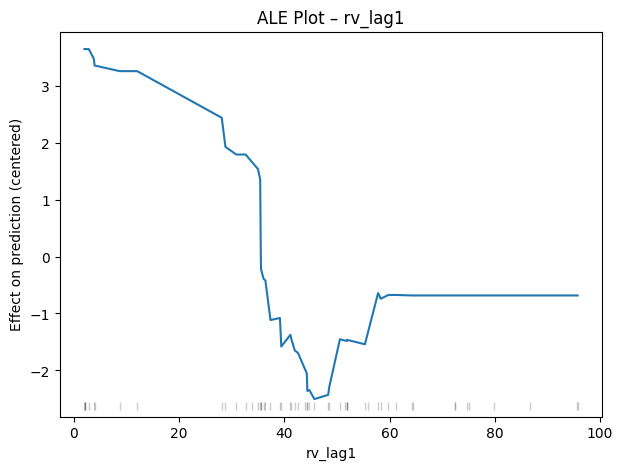

PyALE._ALE_generic:INFO: Continuous feature detected.


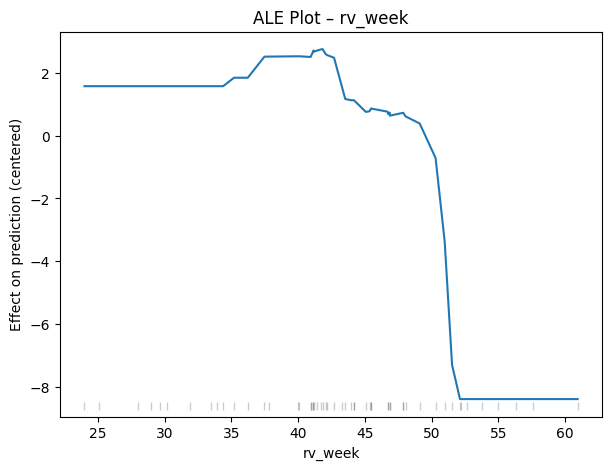

PyALE._ALE_generic:INFO: Continuous feature detected.


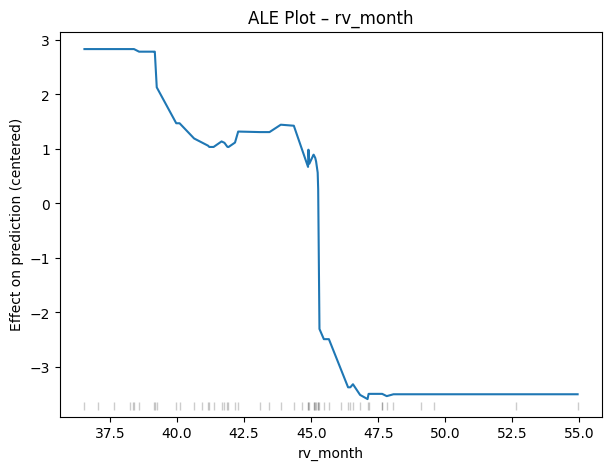

PyALE._ALE_generic:INFO: Continuous feature detected.


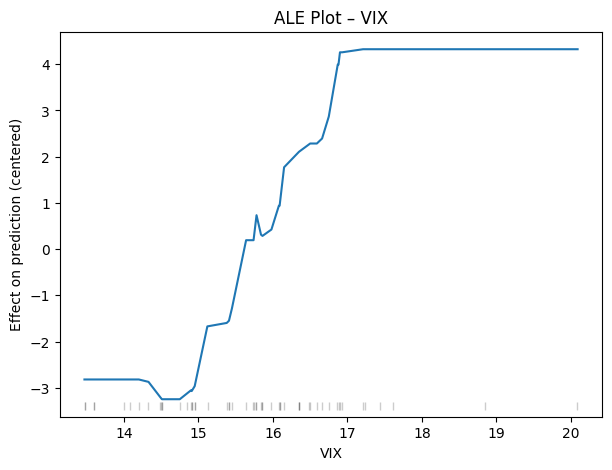

PyALE._ALE_generic:INFO: Continuous feature detected.


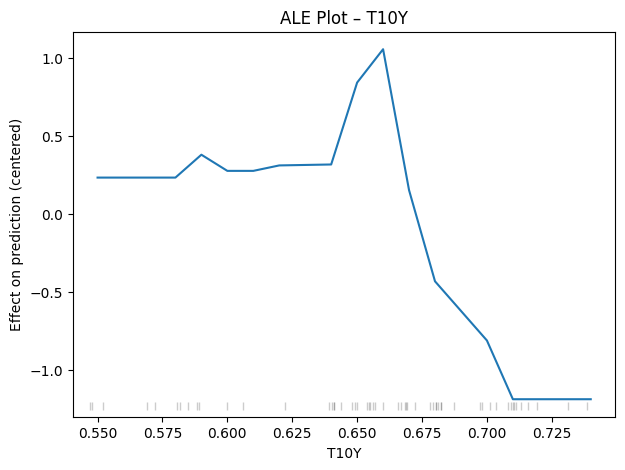

PyALE._ALE_generic:INFO: Continuous feature detected.


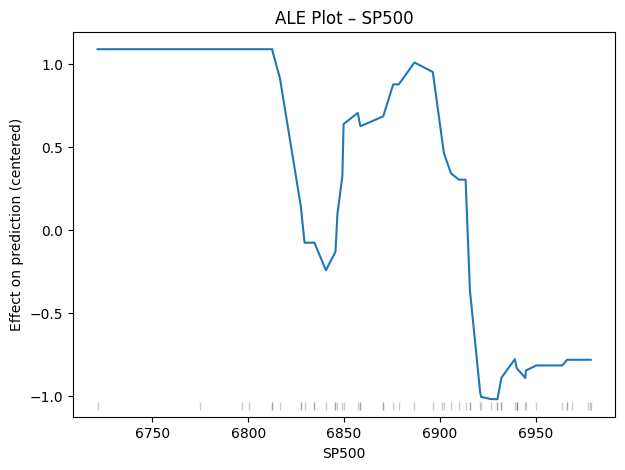

PyALE._ALE_generic:INFO: Continuous feature detected.


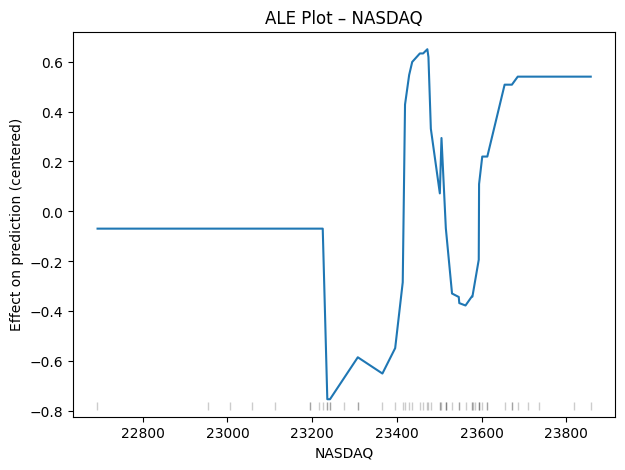

PyALE._ALE_generic:INFO: Continuous feature detected.


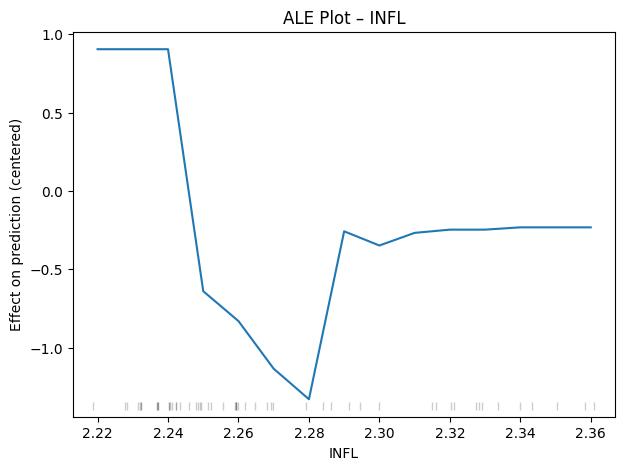

PyALE._ALE_generic:INFO: Discrete feature detected.


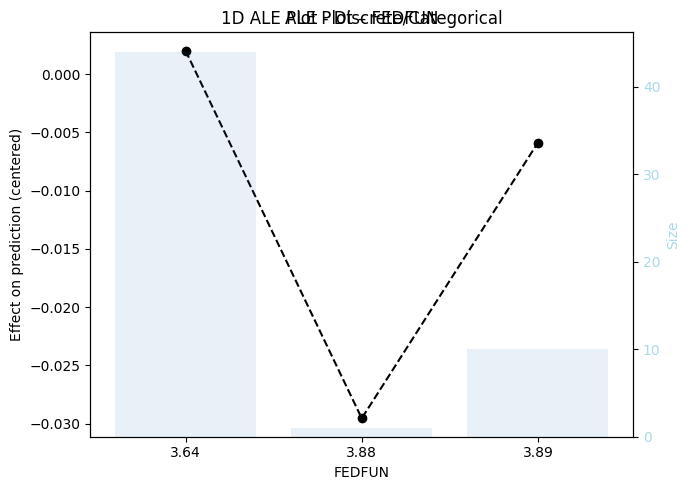

PyALE._ALE_generic:INFO: Continuous feature detected.


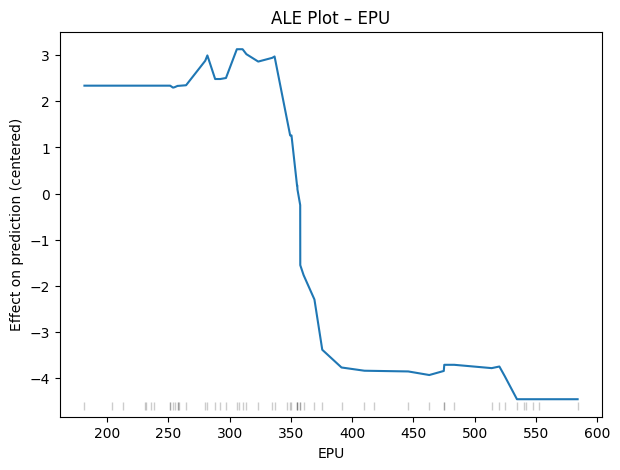

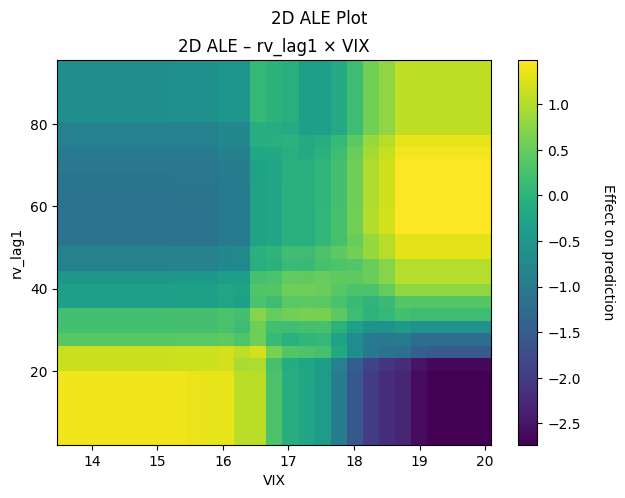

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.



ALE Variable Importance:

rv_week     3.698433
EPU         2.959290
VIX         2.808956
rv_month    2.342898
rv_lag1     1.974211
SP500       0.776790
T10Y        0.686991
INFL        0.654475
NASDAQ      0.425299
FEDFUN      0.013405
dtype: float64


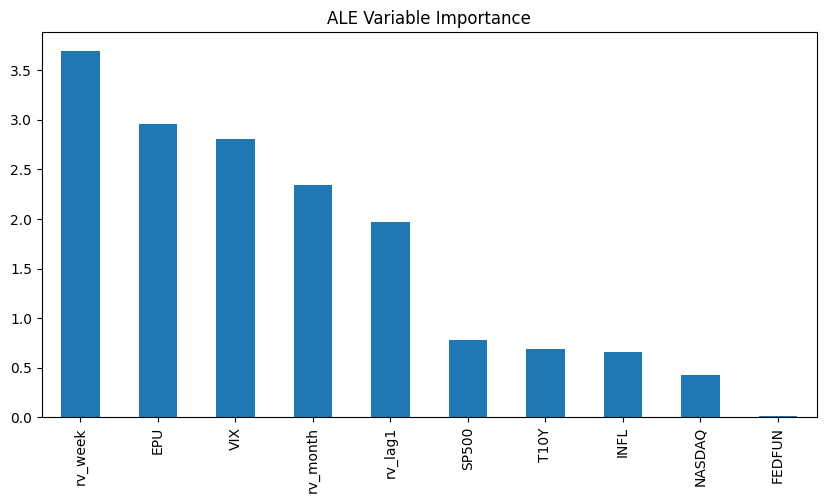

In [32]:
try:
    from PyALE import ale
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "PyALE"])
    from PyALE import ale

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

variables=[
    "rv_lag1","rv_week","rv_month",
    "VIX","T10Y","SP500","NASDAQ",
    "INFL","FEDFUN","EPU"
]
X=df[variables]
y=df["rv"]

J=len(variables)
mtry=max(1,J//3)

# ----------------------------
# Random Forest model (same spec as earlier)
# ----------------------------
rf_model=Pipeline([
    ("scaler",StandardScaler()),
    ("rf",RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=5,
        max_features=mtry,
        bootstrap=True,
        n_jobs=-1,
        random_state=0
    ))
])

rf_model.fit(X,y)

# 1D ALE plots for each variable
for var in variables:
    fig,ax=plt.subplots(figsize=(7,5))
    ale(
        X=X,
        model=rf_model,
        feature=[var],
        grid_size=50,
        include_CI=False,
        plot=True,
        fig=fig,
        ax=ax
    )
    ax.set_title(f"ALE Plot – {var}")
    plt.show()

# 2D ALE interaction example
fig,ax=plt.subplots(figsize=(7,5))
ale(
    X=X,
    model=rf_model,
    feature=["rv_lag1","VIX"],
    grid_size=30,
    plot=True,
    fig=fig,
    ax=ax
)
ax.set_title("2D ALE – rv_lag1 × VIX")
plt.show()

# ALE-based Variable Importance (std of ALE)
vi={}

for var in variables:
    res=ale(
        X=X,
        model=rf_model,
        feature=[var],
        grid_size=50,
        include_CI=False,
        plot=False
    )
    eff=np.array(res["eff"])
    vi[var]=eff.std()

vi_series=pd.Series(vi).sort_values(ascending=False)
print("\nALE Variable Importance:\n")
print(vi_series)

# Optional: bar chart
vi_series.plot(kind="bar",figsize=(10,5),title="ALE Variable Importance")
plt.show()